# Neural Network

## Introduction


*  In fact, Logistic Regression (that have learned in our last session) is the simplest form of Neural Network; Artificial neural networks can be viewed as an extension of Logistic Regression
*  Logistic Regression: results in decision boundaries that are a straight line
*  Neural Networks: can generate more complex decision boundaries
*  (Deep) Neural Networks: a universal approximator!
* In this session, we will learn to use TensorFlow Keras for digit recgonization


## Importing the libraries

In [1]:
%matplotlib inline# Essential imports for neural network implementation# Data manipulation and numerical computingimport numpy as np  # Numerical operationsimport pandas as pd  # Data loading and manipulationimport matplotlib.pyplot as plt  # Visualization# PyTorch - deep learning frameworkimport torch  # Main PyTorch libraryimport torch.nn as nn  # Neural network modulesimport torch.nn.functional as F  # Activation functions and operationsimport torch.optim as optim  # Optimization algorithmsfrom torch.utils.data import DataLoader, TensorDataset  # Data handling# Scikit-learn - machine learning utilitiesfrom sklearn.model_selection import train_test_split  # Data splittingfrom sklearn.preprocessing import StandardScaler  # Feature scalingfrom sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation metricsprint('All required libraries imported successfully!')print(f'PyTorch version: {torch.__version__}')print(f'CUDA available for GPU acceleration: {torch.cuda.is_available()}')

## Importing the dataset

- MNIST is a collection of handwritten digits ranging from the number 0 to 9. 

- It has a training set of 60,000 images, and 10,000 test images that are classified into corresponding categories or labels. 

In [2]:
# Load MNIST dataset from local CSV files# The CSV files have 785 columns: first column is label (0-9), next 784 are pixel values (28x28)train_data = pd.read_csv('mnist_train.csv')test_data = pd.read_csv('mnist_test.csv')# Separate features and labelsX_train = train_data.iloc[:, 1:].values  # All columns except firsty_train = train_data.iloc[:, 0].values   # First column is labelX_test = test_data.iloc[:, 1:].valuesy_test = test_data.iloc[:, 0].valuesprint(f'Training data shape: {X_train.shape}')print(f'Training labels shape: {y_train.shape}')print(f'Test data shape: {X_test.shape}')print(f'Test labels shape: {y_test.shape}')print(f'Unique labels: {np.unique(y_train)}')

11490434/11490434 [==============================] - 3s 0us/step


In [3]:
# count the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))

# count the number of unique test labels
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))

Train labels:  {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}

Test labels:  {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


## Data visualization

- Let's sample the 25 random MNIST digits and visualize them.

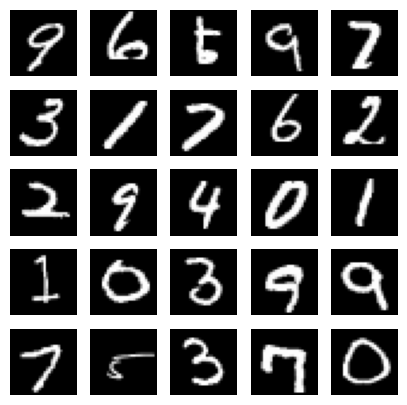

In [4]:
# sample 25 mnist digits from train dataset
indexes = np.random.randint(0, x_train.shape[0], size=25)
images = x_train[indexes]
labels = y_train[indexes]

# plot the 25 mnist digits
plt.figure(figsize=(5,5))
for i in range(len(indexes)):
    plt.subplot(5, 5, i + 1)
    image = images[i]
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    
plt.show()

## Designing model architecture using Keras

## Import Keras layers

In [5]:
# PyTorch model utilities# We'll create a custom neural network class# No additional imports needed beyond what we already have in Cell 3print('PyTorch model utilities ready')print(f'PyTorch version: {torch.__version__}')print(f'CUDA available: {torch.cuda.is_available()}')

## Compute the number of labels

In [6]:
num_labels = len(np.unique(y_train))

## One-Hot Encoding

- At this point, the labels are in digits format, 0 to 9. 
- A more suitable format is called a one-hot vector, a 10-dim vector with all elements 0, except for the index of the digit class. 
- For example, if the label is 2, the equivalent one-hot vector is [0,0,1,0,0,0,0,0,0,0]. The first label has index 0.

In [7]:
# Convert labels to one-hot vectors for consistency with original notebook# Note: PyTorch's CrossEntropyLoss expects class indices, not one-hot# We'll keep one-hot format for educational purposes# Convert to PyTorch tensorsx_train_tensor = torch.FloatTensor(x_train)x_test_tensor = torch.FloatTensor(x_test)y_train_tensor = torch.FloatTensor(y_train)  # One-hoty_test_tensor = torch.FloatTensor(y_test)    # One-hotprint(f'Training tensor shapes: {x_train_tensor.shape}, {y_train_tensor.shape}')print(f'Test tensor shapes: {x_test_tensor.shape}, {y_test_tensor.shape}')

## Data Preprocessing 

In [8]:
# image dimensions (assumed square)
image_size = x_train.shape[1]
input_size = image_size * image_size
input_size

784

In [9]:
# resize and normalize
x_train = np.reshape(x_train, [-1, input_size])
x_train = x_train.astype('float32') / 255
x_test = np.reshape(x_test, [-1, input_size])
x_test = x_test.astype('float32') / 255

## Setting network parameters

- The **batch_size** argument indicates the number of data that we will use for each update of the model parameters.

- **Hidden_units** shows the number of hidden units.

- **Dropout** is the dropout rate (related to **Overfitting and Regularization**).

In [10]:
# network parameters
batch_size = 128
hidden_units = 256
dropout = 0.45

## Designing the model architecture

In [11]:
# Define a 3-layer MLP with ReLU and dropout after each layer# PyTorch version - using nn.Module classclass NeuralNetwork(nn.Module):    def __init__(self, input_size, hidden_units, num_labels, dropout_rate):        super(NeuralNetwork, self).__init__()        self.fc1 = nn.Linear(input_size, hidden_units)        self.dropout1 = nn.Dropout(dropout_rate)        self.fc2 = nn.Linear(hidden_units, hidden_units)        self.dropout2 = nn.Dropout(dropout_rate)        self.fc3 = nn.Linear(hidden_units, num_labels)            def forward(self, x):        x = F.relu(self.fc1(x))        x = self.dropout1(x)        x = F.relu(self.fc2(x))        x = self.dropout2(x)        x = self.fc3(x)        return x# Create model instancemodel = NeuralNetwork(input_size=input_size, hidden_units=hidden_units,                       num_labels=num_labels, dropout_rate=dropout)print('Model architecture:')print(model)print(f'Total parameters: {sum(p.numel() for p in model.parameters())}')print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

## View model summary

- Keras library provides us `summary()` method to check the model description.

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 activation (Activation)     (None, 256)               0         
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 activation_1 (Activation)   (None, 256)               0         
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 10)                2

## How big is our model (number of parameters)?

- From input to Dense layer: 784 × 256 + 256 = 200,960. 

- From first Dense to second Dense: 256 × 256 + 256 = 65,792. 

- From second Dense to the output layer: 10 × 256 + 10 = 2,570. 

- The total is 200,690 + 65,972 + 2,570 = 269,322.

## Compile the model with compile() method

In [13]:
# Define loss function and optimizer# PyTorch equivalent of model.compile()# Since we have one-hot encoded labels, we need to convert back to class indices for CrossEntropyLoss# CrossEntropyLoss expects raw logits (no softmax) and class indices (not one-hot)# We'll use the original y_train (not one-hot) for loss calculation# Convert one-hot back to class indices for loss calculationy_train_indices = torch.argmax(y_train_tensor, dim=1)y_test_indices = torch.argmax(y_test_tensor, dim=1)# Define loss function - CrossEntropyLoss combines LogSoftmax and NLLLosscriterion = nn.CrossEntropyLoss()# Define optimizer - Adam optimizer with learning rateoptimizer = optim.Adam(model.parameters(), lr=0.001)print('Loss function: CrossEntropyLoss')print('Optimizer: Adam (learning rate=0.001)')print('Note: Using class indices for loss calculation')

## Loss function (categorical_crossentropy)

- How far the predicted tensor is from the one-hot ground truth vector is called **loss**.

- In this example, we use **categorical_crossentropy** as the loss function. It is the negative of the sum of the product of the target and the logarithm of the prediction. 

- There are other loss functions in Keras, such as mean_absolute_error and binary_crossentropy. The choice of the loss function is not arbitrary but should be a criterion that the model is learning. 

- For classification by category, categorical_crossentropy or mean_squared_error is a good choice after the softmax activation layer. The binary_crossentropy loss function is normally used after the sigmoid activation layer while mean_squared_error is an option for tanh output.

## Optimization (optimizer adam)

- With optimization, the objective is to minimize the loss function. The idea is that if the loss is reduced to an acceptable level, the model has indirectly learned the function mapping input to output.

- In Keras, there are several choices for optimizers. The most commonly used optimizers are; **Stochastic Gradient Descent (SGD)**, **Adaptive Moments (Adam)** and **Root Mean Squared Propagation (RMSprop)**. 

- Each optimizer features tunable parameters like learning rate, momentum, and decay. 

- Adam and RMSprop are variations of SGD with adaptive learning rates. In the proposed classifier network, Adam is used since it has the highest test accuracy.

## Metrics (accuracy)

- Performance metrics are used to determine if a model has learned the underlying data distribution. The default metric in Keras is loss. 

- During training, validation, and testing, other metrics such as **accuracy** can also be included. 

- **Accuracy** is the percent, or fraction, of correct predictions based on ground truth.

## Train the model with fit() method

In [14]:
# Train the model# PyTorch uses explicit training loops instead of Keras' fit()# Training parametersbatch_size = 128epochs = 10# Create DataLoader for batchingtrain_dataset = TensorDataset(x_train_tensor, y_train_indices)train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)# Lists to track metricstrain_losses = []train_accuracies = []print(f'Starting training for {epochs} epochs...')print('=' * 50)# Training loopfor epoch in range(epochs):    model.train()  # Set model to training mode    running_loss = 0.0    correct = 0    total = 0        for batch_idx, (inputs, labels) in enumerate(train_loader):        # Zero the parameter gradients        optimizer.zero_grad()                # Forward pass        outputs = model(inputs)        loss = criterion(outputs, labels)                # Backward pass and optimize        loss.backward()        optimizer.step()                # Statistics        running_loss += loss.item()        _, predicted = torch.max(outputs.data, 1)        total += labels.size(0)        correct += (predicted == labels).sum().item()                # Print progress every 100 batches        if batch_idx % 100 == 99:            print(f'Epoch {epoch+1}, Batch {batch_idx+1}: Loss = {loss.item():.4f}')        # Calculate epoch statistics    epoch_loss = running_loss / len(train_loader)    epoch_acc = 100 * correct / total    train_losses.append(epoch_loss)    train_accuracies.append(epoch_acc)        print(f'Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')    print('-' * 50)print('Training completed!')print(f'Final training accuracy: {train_accuracies[-1]:.2f}%')

Epoch 1/20
469/469 [==============================] - 9s 14ms/step - loss: 0.6765 - accuracy: 0.8055
Epoch 2/20
469/469 [==============================] - 6s 12ms/step - loss: 0.9206 - accuracy: 0.8121
Epoch 3/20
469/469 [==============================] - 6s 13ms/step - loss: 1.0465 - accuracy: 0.7990
Epoch 4/20
469/469 [==============================] - 5s 12ms/step - loss: 1.0505 - accuracy: 0.7948
Epoch 5/20
469/469 [==============================] - 6s 14ms/step - loss: 1.2337 - accuracy: 0.7885
Epoch 6/20
469/469 [==============================] - 5s 12ms/step - loss: 1.5897 - accuracy: 0.7799
Epoch 7/20
469/469 [==============================] - 6s 13ms/step - loss: 2.3176 - accuracy: 0.7800
Epoch 8/20
469/469 [==============================] - 6s 12ms/step - loss: 3.4941 - accuracy: 0.7798
Epoch 9/20
469/469 [==============================] - 5s 11ms/step - loss: 4.4167 - accuracy: 0.7789
Epoch 10/20
469/469 [==============================] - 5s 11ms/step - loss: 5.3925 - accura

## Evaluating model performance with evaluate() method

In [15]:
# Evaluate the model on test set# PyTorch evaluation loopmodel.eval()  # Set model to evaluation mode (disables dropout, batch norm uses running stats)# Create test DataLoadertest_dataset = TensorDataset(x_test_tensor, y_test_indices)test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)test_loss = 0.0correct = 0total = 0all_predictions = []all_labels = []# Disable gradient computation for evaluationwith torch.no_grad():    for inputs, labels in test_loader:        # Forward pass        outputs = model(inputs)        loss = criterion(outputs, labels)                # Statistics        test_loss += loss.item()        _, predicted = torch.max(outputs.data, 1)        total += labels.size(0)        correct += (predicted == labels).sum().item()                # Store for confusion matrix        all_predictions.extend(predicted.cpu().numpy())        all_labels.extend(labels.cpu().numpy())# Calculate final metricstest_loss = test_loss / len(test_loader)test_accuracy = 100 * correct / totalprint('=' * 50)print('TEST SET EVALUATION')print('=' * 50)print(f'Test Loss: {test_loss:.4f}')print(f'Test Accuracy: {test_accuracy:.2f}%')print(f'Correct/Total: {correct}/{total}')# Confusion matrixfrom sklearn.metrics import confusion_matriximport seaborn as snscm = confusion_matrix(all_labels, all_predictions)print('Confusion Matrix:')print(cm)# Classification reportprint('Classification Report:')print(classification_report(all_labels, all_predictions, target_names=[str(i) for i in range(10)]))

79/79 [==============================] - 1s 11ms/step - loss: 11.6525 - accuracy: 0.8469

Test accuracy: 84.7%


## Neural Network from scratch

- It's for the code session!

## Acknowledgments

Thanks to PRASHANT BANERJEE for creating the open-source [Kaggle jupyter notebook](https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras), licensed under Apache 2.0. It inspires the majority of the content of this slides.